In [1]:
import pandas as pd

annotations = pd.read_csv(
    r"D:\niloy\gnn-bert-music-context-cse715\data\magnatagatune\annotations_final.csv",
    sep="\t"
)

clip_info = pd.read_csv(
    r"D:\niloy\gnn-bert-music-context-cse715\data\magnatagatune\clip_info_final.csv",
    sep="\t"
)

print("annotations shape:", annotations.shape)
print("clip info shape:", clip_info.shape)

annotations shape: (25863, 190)
clip info shape: (31382, 10)


In [2]:
print(annotations.columns.tolist())

['clip_id', 'no voice', 'singer', 'duet', 'plucking', 'hard rock', 'world', 'bongos', 'harpsichord', 'female singing', 'clasical', 'sitar', 'chorus', 'female opera', 'male vocal', 'vocals', 'clarinet', 'heavy', 'silence', 'beats', 'men', 'woodwind', 'funky', 'no strings', 'chimes', 'foreign', 'no piano', 'horns', 'classical', 'female', 'no voices', 'soft rock', 'eerie', 'spacey', 'jazz', 'guitar', 'quiet', 'no beat', 'banjo', 'electric', 'solo', 'violins', 'folk', 'female voice', 'wind', 'happy', 'ambient', 'new age', 'synth', 'funk', 'no singing', 'middle eastern', 'trumpet', 'percussion', 'drum', 'airy', 'voice', 'repetitive', 'birds', 'space', 'strings', 'bass', 'harpsicord', 'medieval', 'male voice', 'girl', 'keyboard', 'acoustic', 'loud', 'classic', 'string', 'drums', 'electronic', 'not classical', 'chanting', 'no violin', 'not rock', 'no guitar', 'organ', 'no vocal', 'talking', 'choral', 'weird', 'opera', 'soprano', 'fast', 'acoustic guitar', 'electric guitar', 'male singer', 'ma

In [3]:
tag_counts = annotations.iloc[:, 1:-1].sum().sort_values(ascending=False)

tag_counts.head(50)

guitar          4852
classical       4272
slow            3547
techno          2954
strings         2729
drums           2598
electronic      2519
rock            2371
fast            2306
piano           2056
ambient         1956
beat            1906
violin          1826
vocal           1729
synth           1717
female          1474
indian          1395
opera           1296
male            1279
singing         1211
vocals          1184
no vocals       1158
harpsichord     1093
loud            1086
quiet           1055
flute           1025
woman           1016
male vocal      1002
no vocal         995
pop              995
soft             985
sitar            926
solo             826
man              741
classic          691
choir            688
voice            665
new age          650
dance            649
female vocal     644
male voice       644
beats            634
harp             623
cello            575
no voice         573
weird            557
country          541
metal        

In [4]:
top_50_tags = tag_counts.head(50).index
task1_data = annotations[['clip_id'] + list(top_50_tags)]

task1_data.shape

(25863, 51)

In [5]:
text_data = clip_info[['clip_id', 'title', 'artist', 'album']]

text_data.head()

,clip_id,title,artist,album
0,2,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
1,6,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
2,10,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
3,11,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
4,12,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas


In [6]:
text_data = clip_info[['clip_id', 'title', 'artist', 'album']].copy()

text_data["text"] = (
    text_data["title"] + " by " +
    text_data["artist"] + " from " +
    text_data["album"]
)

In [7]:
text_data[["clip_id", "text"]].head()

,clip_id,text
0,2,BWV54 - I Aria by American Bach Soloists from ...
1,6,BWV54 - I Aria by American Bach Soloists from ...
2,10,BWV54 - I Aria by American Bach Soloists from ...
3,11,BWV54 - I Aria by American Bach Soloists from ...
4,12,BWV54 - I Aria by American Bach Soloists from ...


In [8]:
text_data[["clip_id", "text"]].tail()

,clip_id,text
31377,58899,La Bressanina by Jacob Heringman from Blame No...
31378,58906,Lost is my Lyberty by Jacob Heringman from Bla...
31379,58907,Lost is my Lyberty by Jacob Heringman from Bla...
31380,58908,Lost is my Lyberty by Jacob Heringman from Bla...
31381,58915,A Toy for Monica Bishop by Jacob Heringman fro...


In [9]:
task1_data = text_data.merge(task1_data, on="clip_id")

task1_data.shape

(25863, 55)

In [10]:
task1_data.head()

,clip_id,title,artist,album,text,guitar,classical,slow,techno,strings,...,male voice,beats,harp,cello,no voice,weird,country,metal,female voice,choral
0,2,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,6,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,10,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,11,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [11]:
task1_data[['title', 'artist', 'album', 'text']].isnull().sum()

title     0
artist    0
album     0
text      0
dtype: int64

In [12]:
task1_data.to_csv(r"D:\niloy\gnn-bert-music-context-cse715\data\processed\task1_data.csv", index=False)

print("Task 1 dataset saved to Processed Folder")

Task 1 dataset saved to Processed Folder


In [13]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    task1_data,
    test_size=0.2,
    random_state=42
)

train_data, val_data = train_test_split(
    train_data,
    test_size=0.2,
    random_state=42
)

print("train:", len(train_data))
print("validation:", len(val_data))
print("test:", len(test_data))

train: 16552
validation: 4138
test: 5173


In [14]:
X_train = train_data["text"]
y_train = train_data[top_50_tags]

X_val = val_data["text"]
y_val = val_data[top_50_tags]

X_test = test_data["text"]
y_test = test_data[top_50_tags]

print(X_train.shape)
print(y_train.shape)

(16552,)
(16552, 50)


In [15]:
# import torch

# print(torch.__version__)
# print(torch.cuda.is_available())
# print(torch.cuda.get_device_name(0))

In [16]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [17]:
train_tokens = tokenizer(
    X_train.tolist(),
    padding=True,
    truncation=True,
    max_length=128
)

val_tokens = tokenizer(
    X_val.tolist(),
    padding=True,
    truncation=True,
    max_length=128
)

test_tokens = tokenizer(
    X_test.tolist(),
    padding=True,
    truncation=True,
    max_length=128
)

train_tokens.keys();

In [18]:
import torch

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(train_tokens["input_ids"]),
    torch.tensor(y_train.values)
)

val_dataset = torch.utils.data.TensorDataset(
    torch.tensor(val_tokens["input_ids"]),
    torch.tensor(y_val.values)
)

test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(test_tokens["input_ids"]),
    torch.tensor(y_test.values)
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

16552
4138
5173


In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

1035
259
324


In [20]:
for i, batch in enumerate(train_loader):
    print(batch[0].shape)
    print(batch[1].shape)
    break

torch.Size([16, 59])
torch.Size([16, 50])


In [21]:
from transformers import BertForSequenceClassification
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=50,
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

print("optimizer ready")

optimizer ready


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

device

device(type='cuda')

In [24]:
import torch.nn as nn

loss_fn = nn.BCEWithLogitsLoss()

In [25]:
import numpy as np
from sklearn.metrics import f1_score, average_precision_score

epochs = 100
patience = 10
best_micro_f1 = 0.0
wait = 0

train_losses = []
val_losses = []
accuracies = []
macro_f1s = []
micro_f1s = []
auc_prs = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch[0].to(device)
        labels = batch[1].float().to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if batch_idx % 100 == 0:
            print(
                f"epoch: {epoch + 1} "
                f"batch: {batch_idx} "
                f"loss: {loss.item():.6f}"
            )

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            input_ids = batch[0].to(device)
            labels = batch[1].float().to(device)

            outputs = model(input_ids=input_ids)
            loss = loss_fn(outputs.logits, labels)

            val_loss += loss.item()

            probabilities = torch.sigmoid(outputs.logits)

            all_probabilities.append(probabilities.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    val_loss /= len(val_loader)

    all_probabilities = np.concatenate(all_probabilities, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    predictions = (all_probabilities >= 0.1).astype(int)

    accuracy = np.mean(all_labels == predictions)

    micro_f1 = f1_score(
        all_labels,
        predictions,
        average="micro",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        predictions,
        average="macro",
        zero_division=0
    )

    auc_pr = average_precision_score(
        all_labels,
        all_probabilities,
        average="macro"
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    accuracies.append(accuracy)
    macro_f1s.append(macro_f1)
    micro_f1s.append(micro_f1)
    auc_prs.append(auc_pr)

    print(
        f"epoch: {epoch + 1} "
        f"train loss: {train_loss:.6f} "
        f"validation loss: {val_loss:.6f}"
    )

    print(
        f"accuracy: {accuracy:.6f} "
        f"macro-f1: {macro_f1:.6f} "
        f"micro-f1: {micro_f1:.6f} "
        f"AUC-PR: {auc_pr:.6f}"
    )

    if micro_f1 > best_micro_f1:
        best_micro_f1 = micro_f1
        wait = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("best model saved")
    else:
        wait += 1
        print(f"no improvement: {wait}")

    if wait >= patience:
        print("early stopping")
        break

epoch: 1 batch: 0 loss: 0.717589
epoch: 1 batch: 100 loss: 0.280916
epoch: 1 batch: 200 loss: 0.191487
epoch: 1 batch: 300 loss: 0.141812
epoch: 1 batch: 400 loss: 0.176236
epoch: 1 batch: 500 loss: 0.160522
epoch: 1 batch: 600 loss: 0.204025
epoch: 1 batch: 700 loss: 0.190998
epoch: 1 batch: 800 loss: 0.174344
epoch: 1 batch: 900 loss: 0.205087
epoch: 1 batch: 1000 loss: 0.163489
epoch: 1 train loss: 0.212485 validation loss: 0.176561
accuracy: 0.870275 macro-f1: 0.150500 micro-f1: 0.302023 AUC-PR: 0.193969
best model saved
epoch: 2 batch: 0 loss: 0.173447
epoch: 2 batch: 100 loss: 0.189599
epoch: 2 batch: 200 loss: 0.181473
epoch: 2 batch: 300 loss: 0.157853
epoch: 2 batch: 400 loss: 0.208046
epoch: 2 batch: 500 loss: 0.185863
epoch: 2 batch: 600 loss: 0.127074
epoch: 2 batch: 700 loss: 0.212553
epoch: 2 batch: 800 loss: 0.140350
epoch: 2 batch: 900 loss: 0.172601
epoch: 2 batch: 1000 loss: 0.148405
epoch: 2 train loss: 0.161565 validation loss: 0.153419
accuracy: 0.869812 macro-f1: 

C:\Users\21101255\AppData\Local\Temp\ipykernel_22252\241121432.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt", map_loca

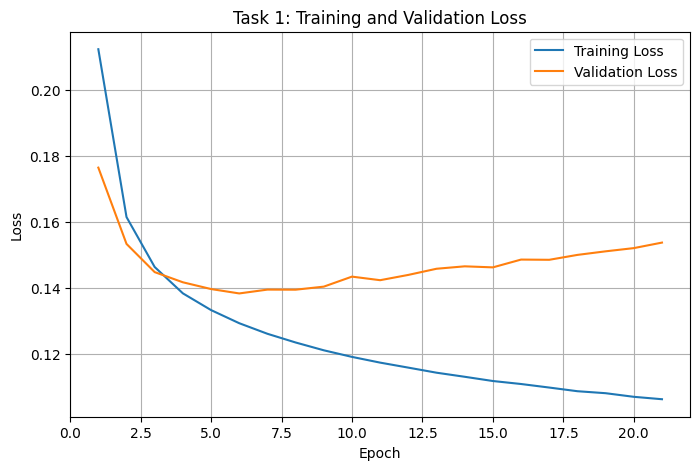

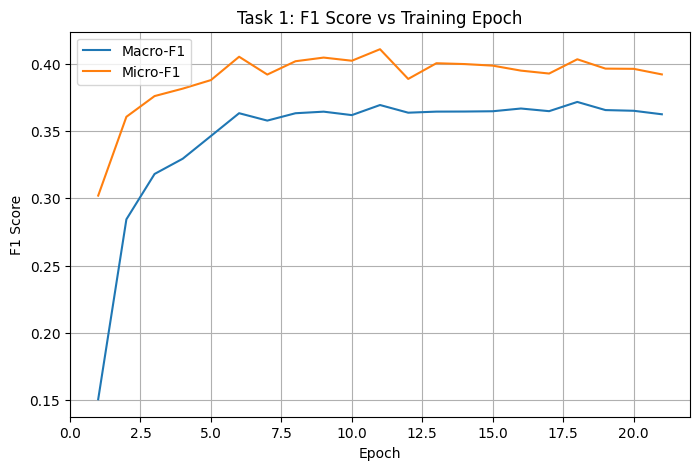

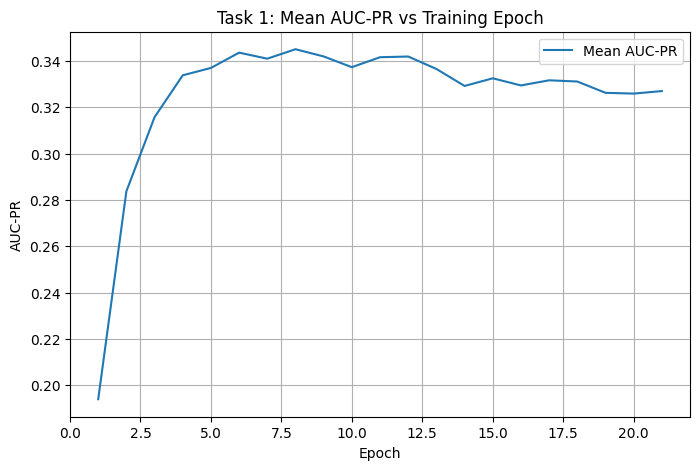

In [26]:
# Load best Task 1 model
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

epochs_completed = range(1, len(train_losses) + 1)

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_completed, train_losses, label="Training Loss")
plt.plot(epochs_completed, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 1: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# F1 curves
plt.figure(figsize=(8, 5))
plt.plot(epochs_completed, macro_f1s, label="Macro-F1")
plt.plot(epochs_completed, micro_f1s, label="Micro-F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Task 1: F1 Score vs Training Epoch")
plt.legend()
plt.grid(True)
plt.show()

# AUC-PR curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_completed, auc_prs, label="Mean AUC-PR")
plt.xlabel("Epoch")
plt.ylabel("AUC-PR")
plt.title("Task 1: Mean AUC-PR vs Training Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
from sklearn.metrics import (
    f1_score,
    average_precision_score
)

model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

test_probabilities = []
test_labels = []

with torch.no_grad():

    for batch in test_loader:
        input_ids = batch[0].to(device)
        labels = batch[1].float().to(device)

        outputs = model(input_ids=input_ids)

        probabilities = torch.sigmoid(outputs.logits)

        test_probabilities.append(probabilities.cpu().numpy())
        test_labels.append(labels.cpu().numpy())

test_probabilities = np.concatenate(test_probabilities, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

test_predictions = (test_probabilities >= 0.1).astype(int)

test_accuracy = np.mean(test_labels == test_predictions)

test_micro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="micro",
    zero_division=0
)

test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_auc_pr = average_precision_score(
    test_labels,
    test_probabilities,
    average="macro"
)

print("===== Task 1 Test Results =====")
print(f"Accuracy (element-wise): {test_accuracy:.4f}")
print(f"Macro-F1:                {test_macro_f1:.4f}")
print(f"Micro-F1:                {test_micro_f1:.4f}")
print(f"Mean AUC-PR:             {test_auc_pr:.4f}")

C:\Users\21101255\AppData\Local\Temp\ipykernel_22252\596851612.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt", map_loca

===== Task 1 Test Results =====
Accuracy (element-wise): 0.8909
Macro-F1:                0.3629
Micro-F1:                0.4048
Mean AUC-PR:             0.3341


In [28]:
tag_names = list(task1_data.columns[5:55])

for i in range(5):
    actual_tags = []
    predicted_tags = []

    for j, tag in enumerate(tag_names):
        if all_labels[i][j] == 1:
            actual_tags.append(tag)
        if predictions[i][j] == 1:
            predicted_tags.append(tag)

    print("Example:", i + 1)
    print("Text:", test_data.iloc[i]["text"])
    print("Actual tags:", actual_tags)
    print("Predicted tags:", predicted_tags)
    print()

Example: 1
Text: Part 2 by Four Stones.Net from Ridin the Faders
Actual tags: []
Predicted tags: ['techno', 'drums', 'electronic', 'rock', 'fast', 'beat', 'vocal', 'singing', 'vocals', 'loud', 'pop']

Example: 2
Text: Suite VI in Re magiore - sarabande by Vito Paternoster from CD1-Bach Cello Suites
Actual tags: ['techno', 'drums', 'rock']
Predicted tags: ['slow', 'vocal', 'female', 'singing', 'woman', 'female vocal', 'female voice']

Example: 3
Text: Wet Brain by Pizzle from Party Patrol
Actual tags: ['rock', 'metal']
Predicted tags: ['guitar', 'drums', 'rock', 'fast', 'loud', 'metal']

Example: 4
Text: Lighting fly by Strojovna 07 from Mirnix
Actual tags: ['classical', 'strings', 'ambient', 'pop']
Predicted tags: ['electronic', 'ambient', 'synth', 'no vocals', 'no vocal', 'new age']

Example: 5
Text: smithee's second by Drop Trio from Cezanne
Actual tags: ['techno', 'electronic', 'synth', 'dance', 'beats']
Predicted tags: ['slow', 'techno', 'electronic', 'ambient', 'beat', 'synth']

